# Effects of Mercury-Contaminated Fish Consumption on Chromosomes

## Dataset Overview

The dataset `mercuryfish`, available in the R package **coin**, comprises measurements of mercury levels in blood, and proportions of cells exhibiting abnormalities and chromosome aberrations. These data are collected from individuals who consume mercury-contaminated fish and a control group with no such exposure. For detailed attributes and dataset structure, refer to the dataset's documentation within the package.

## Objectives

a. **Impact of Methyl-Mercury:** Is the consumption of fish containing methyl-mercury associated with an increased proportion of cellular abnormalities?

b. **Mercury Concentration and Cellular Abnormalities:** How does the concentration of mercury in the blood affect the proportion of cells with abnormalities? Moreover, is there a difference in this relationship between the control group and those exposed to mercury?

c. **Relationship Between Variables:** Does a relationship exist between the proportion of abnormal cells (`abnormal`) and the proportion of cells with chromosome aberrations (`ccells`)? This analysis should be conducted separately for the control and exposed groups to identify any disparities.

## Instructions

In the biostatistics sections of this site, we will be adhering to the following guidelines in order to answer the questions on our objectives:

* **Testing Assumptions:** For all questions necessitating formal inferential statistics, I will conduct and document the appropriate preliminary tests to check statistical assumptions. This includes stating the assumptions, detailing the procedures for testing these assumptions, and specifying the null hypotheses ($H_{0}$). If assumptions are tested graphically, I will elucidate the rationale behind the graphical method. I will also discuss the outcomes of these assumption tests and provide a rationale for the chosen inferential statistical tests (e.g., *t*-test, ANOVA).

* **State Hypotheses:** When inferential statistics are employed, I will clearly articulate the null ($H_{0}$) and alternative ($H_{A}$) hypotheses. 

* **Graphical Support:** Support all descriptive and inferential statistical analyses with appropriate graphical representations of the data.

* **Formatting:** Presentation matters. The visual quality of the page will be made to my utmost best. This includes the neatness of the document, proper use of headings, and adherence to coding conventions (e.g., spacing).

Before we begin with the analyses, I first want to prevent warning messages from appearing on my code block. *This method can be ignored when you are using RStudio or base R to do your coding. I am only using it because I am using an R kernel in Jupyter Notebook.*

In [2]:
options(warn = 1)

# Set to 0 to enable warnings
# Set to 1 to remove warnings

### **a. Impact of Methyl-Mercury**

First and foremost, we have to install the **coin** package in order to access the mercury data, as well as **tidyverse**, which is a collection of packages designed to make common data tasks like data cleaning, manipulation, and visualisation more intuitive and efficient compared to base R:

In [ ]:
install.packages("coin")
install.packages("tidyverse")

After installing the packages, we can then move on to loading the data and analysing it:

In [5]:
library(tidyverse)
library(coin)
data(mercuryfish)

In [27]:
# Check the structure of the dataset

head(mercuryfish)

,group,mercury,abnormal,ccells,residuals,residuals2
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,control,5.3,8.6,2.7,3.9501403,0.1489412
2,control,15.0,5.0,0.5,0.2997661,-0.6993738
3,control,11.0,8.4,0.0,3.7205390,-2.4759652
4,control,5.8,1.0,0.0,-3.6524563,0.3024985
5,control,17.0,13.0,5.0,8.2893797,0.7968817
6,control,7.0,5.0,0.0,0.3413119,-1.1993738


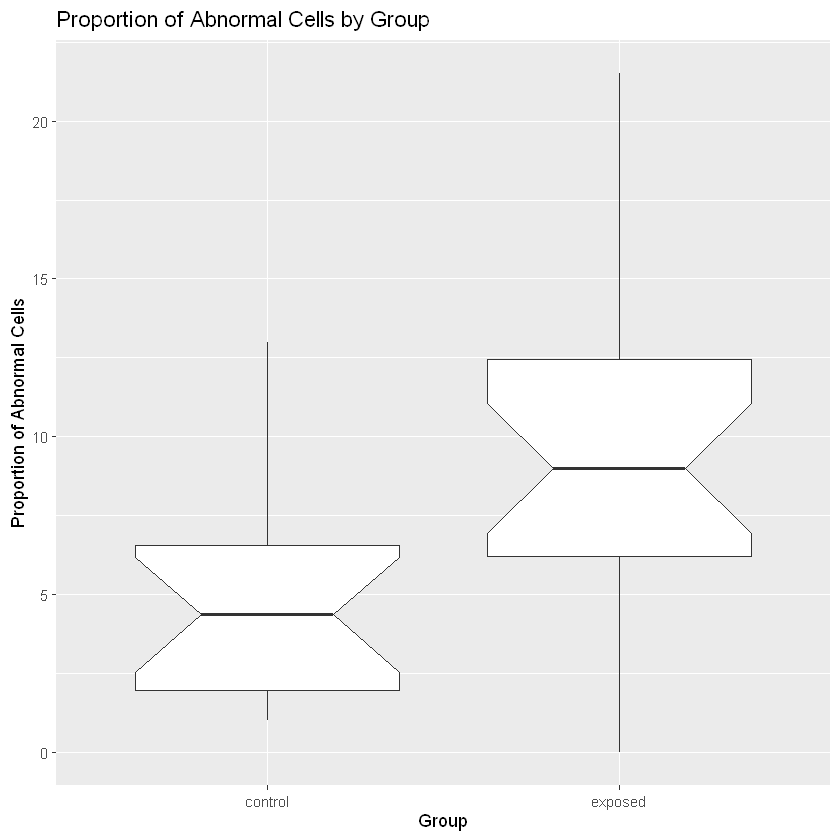

In [9]:
# EDA: Boxplot of the proportion of abnormal cells by group
  
ggplot(mercuryfish, aes(x = group, y = abnormal)) +
geom_boxplot(notch = TRUE) +
labs(title = "Proportion of Abnormal Cells by Group",
         x = "Group",
         y = "Proportion of Abnormal Cells")

In the above plot, we can see that the exposed group has a higher proportion of abnormal cells. Let us test this formally...

First we will run the Shapiro-Wilk test to test the normality of the data within the groups. My $H_{0}$ and $H_{A}$ are:

* **$H_{0}$ : The distribution of my data does not differ from a normal distribution**
* **$H_{A}$ : The distribution of my data differs from a normal distribution**

In [10]:
shapiro.test(mercuryfish$abnormal[mercuryfish$group == "control"])


	Shapiro-Wilk normality test

data:  mercuryfish$abnormal[mercuryfish$group == "control"]
W = 0.90267, p-value = 0.0887


In [11]:
shapiro.test(mercuryfish$abnormal[mercuryfish$group == "exposed"])


	Shapiro-Wilk normality test

data:  mercuryfish$abnormal[mercuryfish$group == "exposed"]
W = 0.96841, p-value = 0.6509


From the above test, we see that we can accept the assumption of normality for both groups **(*p-value* > 0.05)**.

Now what about homogeneity of variances?

In [12]:
mercuryfish |> 
group_by(group) |>
summarise(sample_var = var(abnormal))

group,sample_var
<fct>,<dbl>
control,11.20496
exposed,24.31632


We see that the exposed group's variance is more than double that of the control group, suggesting a difference in the spread of our data. This indicates that homoscadasticity has been violated. We can do a Levene's test to confirm this.

**Levene's test**
* **$H_{0}$ : The variances of the groups are equal**
* **$H_{A}$ : The variances of the groups are not equal**

In [13]:
car::leveneTest(abnormal ~ group, data = mercuryfish)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1,1.660731,0.2055044
,37,NA,NA


From the above test, we see that we accept the $H_{0}$ that states that the variances are equal **(*p-value* > 0.05)** despite seeing the raw variance of the exposed group being numerically double that of the control group.

We can now infer that the data are normally distributed and variances are equal, and we can proceed with a Student's t-test to compare the proportion of abnormal cells between the two groups.

In [14]:
t.test(abnormal ~ group, var.equal = TRUE, data = mercuryfish)


	Two Sample t-test

data:  abnormal by group
t = -2.9664, df = 37, p-value = 0.005253
alternative hypothesis: true difference in means between group control and group exposed is not equal to 0
95 percent confidence interval:
 -7.084765 -1.334257
sample estimates:
mean in group control mean in group exposed 
             4.668750              8.878261 


The *p-value* is less than 0.05, indicating a significant difference in the proportion of abnormal cells between the control and exposed groups.

### b. Mercury Concentration and Cellular Abnormalities

`geom_smooth()` using formula = 'y ~ x'


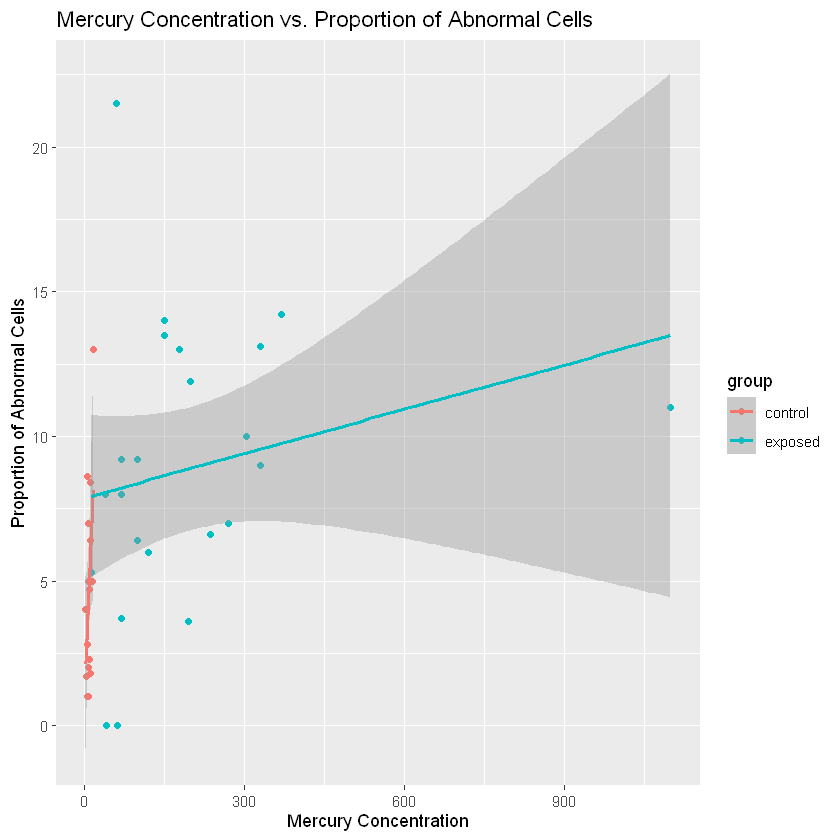

In [15]:
 # EDA: Scatterplot of mercury concentration vs. proportion of abnormal cells
  
  ggplot(mercuryfish, aes(x = mercury, y = abnormal, color = group)) +
    geom_point() +
    geom_smooth(method = "lm", se = TRUE) +
    labs(title = "Mercury Concentration vs. Proportion of Abnormal Cells",
         x = "Mercury Concentration",
         y = "Proportion of Abnormal Cells")

We will follow the same procedure as before; we will begin by testing for normality of the data:

In [16]:
shapiro.test(mercuryfish$mercury[mercuryfish$group == "control"])


	Shapiro-Wilk normality test

data:  mercuryfish$mercury[mercuryfish$group == "control"]
W = 0.97435, p-value = 0.9032


In [17]:
shapiro.test(mercuryfish$mercury[mercuryfish$group == "exposed"])


	Shapiro-Wilk normality test

data:  mercuryfish$mercury[mercuryfish$group == "exposed"]
W = 0.64984, p-value = 3.341e-06


We can see that the mercury concentrations are normally distributed for the control group (we do not reject $H_{0}$) but not for the exposed group (we reject $H_{0}$); earlier we have seen that the response variable (abnormalities) is normal for both the control and the exposed groups. But since we want to model a linear relationship, now is not quite the right time to do the tests for normality - we want to do this for the residuals of the model (that is, we fit the model first, and then test the residuals for normality).
  

We also see from the scatterplot that the data might be approximately linear for the exposed group, but not for the control group where the data are more scattered around very low mercury concentrations near zero. We also see from the very wide confidence inrtervals that the model is not very good at predicting the proportion of abnormal cells from mercury concentration in the blood in the exposed group; my guess is that there will not be a linear relationship between mercury concentration and the proportion of abnormal cells in the control or exposed groups.

   
We can proceed with a linear regression model to assess the relationship between mercury concentration and the proportion of abnormal cells.
  
* **$H_{0}$(1): There is no relationship between mercury concentration and the proportion of abnormal cells**
* **$H_{A}$(1): There is a relationship between mercury concentration and the proportion of abnormal cells**
* **$H_{0}$(2): The relationship between mercury concentration and the proportion of abnormal cells does not differ between the control and exposed groups**
* **$H_{A}$(2): The relationship between mercury concentration and the proportion of abnormal cells differs between the control and exposed groups**

In [18]:
model.lm <- lm(abnormal ~ mercury + group, data = mercuryfish)
summary(model.lm)


Call:
lm(formula = abnormal ~ mercury + group, data = mercuryfish)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.1709 -2.5884 -0.2124  2.6725 13.3395 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.622336   1.081910   4.272 0.000135 ***
mercury      0.005193   0.004129   1.258 0.216575    
groupexposed 3.226585   1.610348   2.004 0.052677 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.325 on 36 degrees of freedom
Multiple R-squared:  0.2261,	Adjusted R-squared:  0.1832 
F-statistic:  5.26 on 2 and 36 DF,  p-value: 0.009906


We can now check the residuals for normality in the two groups which will confirm that the model is appropriate (or not):

In [20]:
mercuryfish$residuals <- residuals(model.lm)

shapiro.test(mercuryfish$residuals[mercuryfish$group == "control"])


	Shapiro-Wilk normality test

data:  mercuryfish$residuals[mercuryfish$group == "control"]
W = 0.90326, p-value = 0.09066


In [21]:
shapiro.test(mercuryfish$residuals[mercuryfish$group == "exposed"])


	Shapiro-Wilk normality test

data:  mercuryfish$residuals[mercuryfish$group == "exposed"]
W = 0.94985, p-value = 0.2905


We see that the residuals are normally distributed for both groups and hence using a linear model was appropriate.


The p-value for the interaction term not less than 0.05, indicating that the relationship between mercury concentration and the proportion of abnormal cells does not differ between the control and exposed groups - we can reject $H_{A}$(1) and $H_{A}$(2). If we wanted to (recommended), we could refit the model without the interaction term. We could also do an ANCOVA instead of the linear model to test the interaction term.

In [22]:
model.aov <- aov(abnormal ~ group * mercury, data = mercuryfish)
  summary(model.aov)

              Df Sum Sq Mean Sq F value  Pr(>F)   
group          1  167.2  167.20   9.246 0.00445 **
mercury        1   29.6   29.59   1.636 0.20924   
group:mercury  1   40.5   40.47   2.238 0.14361   
Residuals     35  633.0   18.08                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

**What do we conclude?**

The proportion of abnormal cells differs significantly between the control and exposed groups, with the exposed group exhibiting a higher proportion of abnormal cells. However, the relationship between mercury concentration and the proportion of abnormal cells does not differ between the two groups. There is a good amount of scatter in the amount of cell abnormalities even in just the control group, which suggests that mercury concentration alone may not be a strong predictor of cellular abnormalities. Increasing the amount of mercury in the blood does not necessarily lead to a linear increase but it certainly does account for a few of the highest values seen in the exposed group.

### c. Relationship Between Variables

`geom_smooth()` using formula = 'y ~ x'


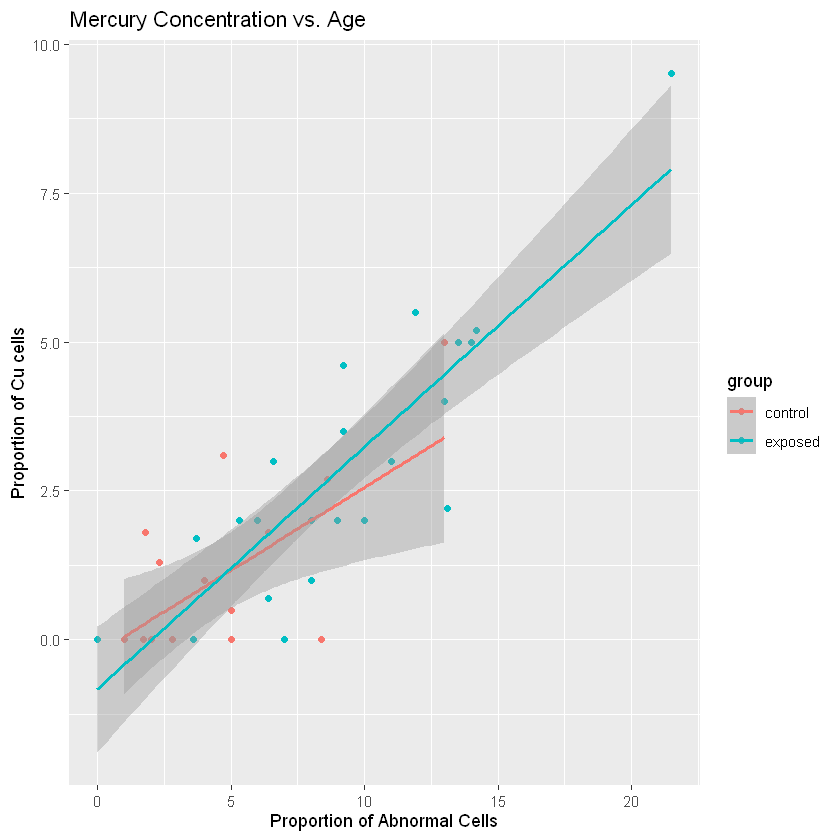

In [23]:
# EDA: Scatterplot of mercury concentration vs. age
  
  ggplot(mercuryfish, aes(x = abnormal, y = ccells, color = group)) +
    geom_point() +
    geom_smooth(method = "lm", se = TRUE) +
    labs(title = "Mercury Concentration vs. Age",
         x = "Proportion of Abnormal Cells",
         y = "Proportion of Cu cells")

We can see that there is a clear linear relationship between abnormal cell proportion and Cu cell proportion in both groups, and the confidence intervals are narrow(-ish), indicating that the model could be reasonably good at predicting Cu cell proportion from the proportion of abnormal cells.
  

We know the relationship between continuous covariates is linear and may therefore proceed with a linear regression model; the remaining assumptions will be tested afterwards.
  
* **$H_{0}$(1): There is no relationship between the proportion of Cu cells and the proportion of abnormal cells**
* **$H_{A}$(1): There is a relationship between the proportion of Cu cells and the proportion of abnormal cells**
* **$H_{0}$(2): The relationship between the proportion of Cu cells and the proportion of abnormal cells does not differ between the control and exposed groups**
* **$H_{A}$(2): The relationship between the proportion of Cu cells and the proportion of abnormal cells differs between the control and exposed groups**

In [24]:
model.lm2 <- lm(ccells ~ abnormal + group, data = mercuryfish)
summary(model.lm2)


Call:
lm(formula = ccells ~ abnormal + group, data = mercuryfish)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4760 -0.7479  0.1761  0.5831  2.0133 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -0.67797    0.36166  -1.875    0.069 .  
abnormal      0.37547    0.04461   8.417 5.01e-10 ***
groupexposed  0.12272    0.42837   0.286    0.776    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.183 on 36 degrees of freedom
Multiple R-squared:  0.7152,	Adjusted R-squared:  0.6994 
F-statistic: 45.21 on 2 and 36 DF,  p-value: 1.516e-10


We can now check the residuals for normality in the two groups which will confirm that the model is appropriate (or not)

In [25]:
mercuryfish$residuals2 <- residuals(model.lm2)

shapiro.test(mercuryfish$residuals2[mercuryfish$group == "control"])


	Shapiro-Wilk normality test

data:  mercuryfish$residuals2[mercuryfish$group == "control"]
W = 0.95476, p-value = 0.5686


In [26]:
shapiro.test(mercuryfish$residuals2[mercuryfish$group == "exposed"])


	Shapiro-Wilk normality test

data:  mercuryfish$residuals2[mercuryfish$group == "exposed"]
W = 0.96346, p-value = 0.5366


We see that the residuals are normally distributed for both groups and hence using a linear model was appropriate.


The *p-value* 'abnormal' term is less than 0.05, indicating that the relationship between the proportion of abnormal cells and the proportion of Cu cells is significant - we accept $H_{A}$(1). The *p-value* for the interaction term is not less than 0.05, indicating that the relationship between the proportion of abnormal cells and the proportion of Cu cells does not differ between the control and exposed groups - we do not reject $H_{0}$(2).
    
**What do we conclude?**

The proportion of Cu cells is significantly related to the proportion of abnormal cells, with a higher proportion of abnormal cells corresponding to a higher proportion of Cu cells. This relationship does not differ between the control and exposed groups. The model is appropriate for predicting the proportion of Cu cells from the proportion of abnormal cells, as the residuals are normally distributed for both groups.